In [1]:
from getmetricsutils import *

In [3]:
modelf = "/projects/vsokolov/timing-austin/"
expf="experiments"
output_dir_name = "Austin"
config = "scratch/config_morris_timing.json"
metrics_file = f'{modelf}/scratch/aus-mc-timing-conv.csv'

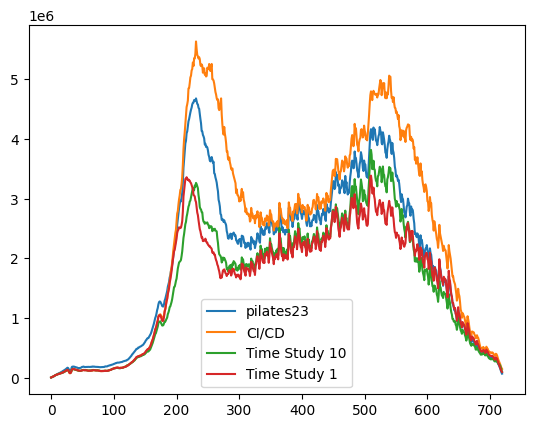

In [9]:
dmoe = getnet("/home/vsokolov"); plt.plot(dmoe)
dmoe = getnet("/home/vsokolov/Austin"); plt.plot(dmoe)
moe = getnet("/home/vsokolov/projects/timing-austin/experiments/SimTestClean/Austin_iteration_10"); plt.plot(moe)
moe = getnet("/home/vsokolov/projects/timing-austin/experiments/SimTestClean/Austin_iteration_1"); plt.plot(moe)
plt.legend(["pilates23", "CI/CD", "Time Study 10", "Time Study 1"])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


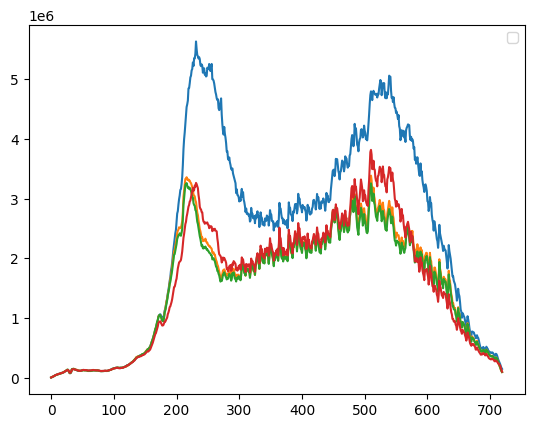

In [7]:
dmoe = getnet("/home/vsokolov/Austin"); plt.plot(dmoe)
moe = getnet("/home/vsokolov/projects/timing-austin/experiments/SimTestClean/Austin_iteration_1"); plt.plot(moe)
moe = getnet("/home/vsokolov/projects/timing-austin/experiments/SimTestClean/Austin_iteration_2"); plt.plot(moe)
moe = getnet("/home/vsokolov/projects/timing-austin/experiments/SimTestClean/Austin_iteration_10"); plt.plot(moe)
plt.legend()

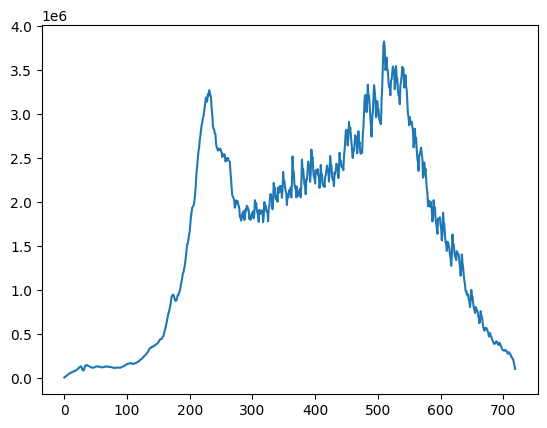

In [5]:
moe = getnet("/home/vsokolov/projects/timing-austin/experiments/SimTestClean/Austin_iteration_10"); plt.plot(moe)

In [22]:
st = pd.DataFrame(columns=['design','iteration', 'f'])
for sf in glob.glob(f'{modelf}/{expf}/*/Austin_iteration_*'):
    print(sf)
    it = int(sf.split('/')[-1].split('_')[-1])
    sim = int(sf.split('/')[-2][3:])
    moe = getnet(sf)
    st.loc[len(st)] = [sim, it, np.mean(np.abs(moe - dmoe))] 
        

/projects/vsokolov/timing-austin//experiments/Sim0/Austin_iteration_10
/projects/vsokolov/timing-austin//experiments/Sim0/Austin_iteration_2
/projects/vsokolov/timing-austin//experiments/Sim0/Austin_iteration_3
/projects/vsokolov/timing-austin//experiments/Sim0/Austin_iteration_4
/projects/vsokolov/timing-austin//experiments/Sim0/Austin_iteration_5
/projects/vsokolov/timing-austin//experiments/Sim0/Austin_iteration_6
/projects/vsokolov/timing-austin//experiments/Sim0/Austin_iteration_7
/projects/vsokolov/timing-austin//experiments/Sim0/Austin_iteration_8
/projects/vsokolov/timing-austin//experiments/Sim0/Austin_iteration_9
/projects/vsokolov/timing-austin//experiments/Sim1/Austin_iteration_10
/projects/vsokolov/timing-austin//experiments/Sim1/Austin_iteration_2
/projects/vsokolov/timing-austin//experiments/Sim1/Austin_iteration_3
/projects/vsokolov/timing-austin//experiments/Sim1/Austin_iteration_4
/projects/vsokolov/timing-austin//experiments/Sim1/Austin_iteration_5
/projects/vsokolov

ValueError: invalid literal for int() with base 10: 'Test'

In [23]:
st.to_csv('moe-gap-austim-timing.csv', index=False)

In [ ]:
# Check if all are complete
for folder in  glob.glob(f'{modelf}/{expf}/**'):
    if not os.path.isfile(f'{folder}/{output_dir_name}/finished'):
        print(f'{folder}/finished does not exist')

        

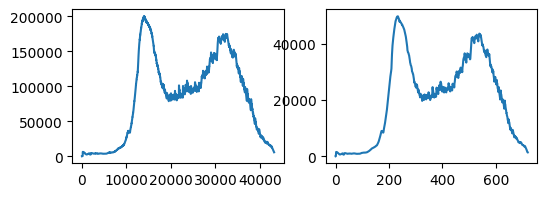

In [10]:
plotsum('/home/vsokolov/Austin23/Austin_iteration_10/')

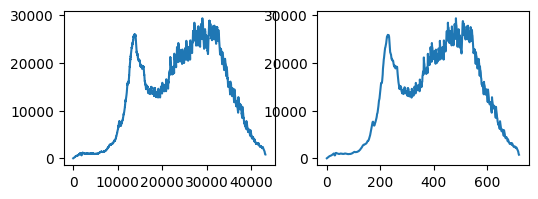

In [9]:
plotsum(f'../{expf}/Sim5/{output_dir_name}_iteration_10')

In [ ]:
with open(f"{modelf}/{config}",'r') as fh:
    config = json.load(fh)
polaris_json_file = list(config.keys())[0]
vars = [item['name'] for item in config[polaris_json_file]]
print(polaris_json_file)
print(vars)

control_files = glob.glob(f'{modelf}/{expf}/**/{polaris_json_file}')
with open(control_files[0]) as fh:
    data = json.load(fh)
root_key = list(data.keys())[0]
root_key

In [ ]:
d = []
for sim in control_files:    
    with open(sim) as fh:
        data = json.load(fh)
    vals = [data[root_key][item] for item in vars]
    vals= vals+[os.path.dirname(sim)]
    d.append(vals)

In [ ]:
df = pd.DataFrame(d, columns=vars+['folder'])
df.iloc[0:3]
df.tail()
# df.to_csv('vals-folder.csv', index=False)

In [21]:
df = pd.read_csv('../scratch/aus-mc-timing.csv')
df.head()

,S_AMPEAK_TT,S_AMOFFPEAK_TTV,S_AMOFFPEAK_TT,S_PMOFFPEAK_TT,S_PMPEAK_TT,S_EVENING_TT,S_AMOFFPEAK_OCCUPANCY,S_PMOFFPEAK_OCCUPANCY,S_PMPEAK_OCCUPANCY,D_AMPEAK_OCCUPANCY,...,m7,m8,m9,m10,m15,m17,m18,m999,m1001,m1015
0,-0.333333,0.000000,-1.000000,-1.000000,-1.000000,0.0,-0.333333,-0.333333,-1.000000,-1.000000,...,24035,103111,22213,73100,3671,49573,62330,1854,358,83660
1,-0.333333,0.000000,-0.333333,-1.000000,-1.000000,0.0,-0.333333,-0.333333,-1.000000,-1.000000,...,23932,97057,21952,73091,3663,49573,62330,1786,361,86082
2,-0.333333,-0.666667,-0.333333,-0.333333,-0.333333,0.0,-1.000000,-1.000000,-0.333333,-0.333333,...,24081,94596,23082,72620,3638,49573,62330,1743,293,84830
3,-1.000000,-0.333333,-1.000000,-0.666667,-0.666667,-1.0,-0.666667,-0.333333,-1.000000,-1.000000,...,0,0,0,0,0,0,0,0,0,0
4,-1.000000,-0.333333,-1.000000,-0.666667,-0.666667,-1.0,0.000000,-0.333333,-1.000000,-1.000000,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
def get_diurnal_mode(i):
    f = df.loc[i,'folder']
    if not os.path.isfile(f"{f}/{output_dir_name}/finished"):
        print(f'{f}/finished does not exist')
        return f
    con = sqlite3.connect(f"{f}/{output_dir_name}/Austin-Demand.sqlite")
    trip = pd.read_sql_query("SELECT start,mode from trip", con)
    bins= np.arange(0, 60*60*24, 20*60)
    groups = trip.groupby(['mode', pd.cut(trip.start, bins)])
    groups.size().unstack().transpose().to_csv(f"../scratch/diurnal-mode/{f.split('/')[-1]}-dm.csv", index=False)
    return f
# get_diurnal_mode(0)

In [ ]:
# with futures.ThreadPoolExecutor(10) as executor:
#     result = executor.map(get_diurnal_mode, range(len(df)))
#     for res in result:
#         print(res)

In [ ]:
f = df.loc[0,'folder']
con = sqlite3.connect(f"{f}/{output_dir_name}/Austin-Demand.sqlite")
res = con.execute("select mode, count(*) from Trip group by mode").fetchall()
mode, share = ([i for i, j in res],[j for i, j in res])
print(mode,share)
for i in mode:
    df[f'm{i}'] = 0
df.head()
df.tail()

In [ ]:
def get_demand(i):
    f = df.loc[i,'folder']
    with open(f'{f}/{output_dir_name}/log/polaris_progress.log','r') as fh:
        if fh.readlines() [-3:][0].find('Finished') == -1:
            return(False, f"{f} is not finished, skipping")
    con = sqlite3.connect(f"{f}/{output_dir_name}/Austin-Demand.sqlite")
    res = con.execute("select mode, count(*) from Trip group by mode").fetchall()
    mode, share = ([i for i, j in res],[j for i, j in res])
    for j in range(len(mode)):
        df.loc[i,f'm{mode[j]}'] = share[j]#/sum(share)
    return(True, f"{f} {share[0]}")

In [ ]:
with futures.ThreadPoolExecutor(20) as executor:
    result = executor.map(get_demand, range(len(df)))
    for res in result:
        flag, msg = res
        if not flag:
            print(msg)

In [ ]:
(df['m0']/df['m0'].sum()).plot()

In [ ]:
df['net'] = 0.0
df.head()

In [ ]:
def get_network_metrics(db):
    with h5py.File(db, 'r') as f:
        # ref_output = f['link_moe']['link_travel_time'][:]*f['link_moe']['link_in_volume'][:]
        res = f['link_moe']['num_vehicles_in_link'][:]
        res =  np.sum(res, axis=1)
    return res
def get_network(i,refout):
    f = df.loc[i,'folder']
    db = f'{f}/{output_dir_name}/Austin-Result.h5'
    out = get_network_metrics(db)
    res = np.mean(np.abs(out-refout))
    df.loc[i,'net'] = res
    # print(f"{f} {res}")
    return(res)

In [ ]:
refout = get_network_metrics("/home/vsokolov/Austin/Austin_iteration_10/Austin-Result.h5")
plt.plot(refout)

In [ ]:
get_network(0,refout)
df.head()

In [ ]:
with futures.ThreadPoolExecutor(10) as executor:
    result = executor.map(get_network, range(len(df)),repeat(refout))
    for res in result:
        print(res)  

In [ ]:
df.head()

In [ ]:
df.to_csv(metrics_file, index=False)